```cpp

/*
CUDA c++ code for biophysics assignment
Written by Yun Wooyoung
*/


#include <iostream>
#include <vector>
#include <curand_kernel.h>

#include "cnpy.h" //https://github.com/rogersce/cnpy


__global__ void init_rng(curandState *states, unsigned long seed, int N){
    int idx = threadIdx.x + blockDim.x*blockIdx.x;

    if (idx >= N) return;

    curand_init(seed, idx, 0, &states[idx]);
}


__global__ void init_state(float *x_t, float *y_t, int N){
    int idx = threadIdx.x + blockDim.x*blockIdx.x;

    if (idx >= N) return;

    x_t[idx] = 2.5f;
    y_t[idx] = 2.5f;
}


__device__ bool isInBuffer(float x, float y, const float L, const float b){
    bool near_vertical_wall = (x > 0.5f*L - b) && (x < 0.5f*L + b);
    bool near_horizontal_wall = (y > 0.5f*L - b) && (y < 0.5f*L + b);

    return near_vertical_wall || near_horizontal_wall;
}


__global__ void Brownian(float *x_t, float *y_t, int *count, curandState *states, const int N, const int N_threshold, const float L, const float b){
    int idx = threadIdx.x + blockDim.x*blockIdx.x;

    if (idx >= N) return;

    curandState local = states[idx];

    float x = x_t[idx];
    float y = y_t[idx];
    int c = count[idx];

    float dx = curand_normal(&local)*0.12f;
    float dy = curand_normal(&local)*0.12f;

    float x_next = x + dx;
    float y_next = y + dy;

    // Always in system
    if (x_next < 0) {x_next *= -1;}
    if (y_next < 0) {y_next *= -1;}
    if (x_next > L) {x_next = 2.0f*L - x_next;}
    if (y_next > L) {y_next = 2.0f*L - y_next;}

    bool crossed = ((x >= 0.5f*L) != (x_next >= 0.5f*L)) || ((y >= 0.5f*L) != (y_next >= 0.5f*L)); // Is particle crossed the wall?

    if (crossed && (c < N_threshold)) {
        // If crossed but c < N_threshold: reject
        x_next = x;
        y_next = y;
    }

    c = isInBuffer(x_next, y_next, L, b) ? c + 1 : 0;

    x_t[idx] = x_next;
    y_t[idx] = y_next;
    count[idx] = c;
    states[idx] = local;
}



int main() {
    const int N = 30; // Number of particles
    const int Nt = 2500; // Number of time stpes
    const int N_threshold = 15; // Number of time stpes holding in the threshold
    const float L = 10.0f; // System size
    const float b = 0.4f; // Buffer size

    int bytes = N*sizeof(float); // Size of float array

    int blockSize = 64; // Threads per block
    int gridSize = (N + blockSize - 1)/blockSize ; // Number of block
    
    // RNG initialization
    curandState *states;
    cudaMalloc(&states, N*sizeof(curandState));
    init_rng<<<gridSize, blockSize>>>(states, 10, N);
    cudaDeviceSynchronize();

    // x Initialization
    float *x, *x_t;
    float *y, *y_t;
    int *count;

    cudaMalloc(&x_t, bytes); // Current x_i(t)
    cudaMalloc(&x, Nt*bytes); // Total trajectories of x_i
    cudaMalloc(&y_t, bytes); // Current y_i(t)
    cudaMalloc(&y, Nt*bytes); // Total trajectories of y_i
    cudaMalloc(&count, N*sizeof(int));

    init_state<<<gridSize, blockSize>>>(x_t, y_t, N);
    cudaDeviceSynchronize();

    // Stochastic dynamics
    for (int t = 0; t < Nt; ++t) {
        cudaMemcpy(x + t*N, x_t, bytes, cudaMemcpyDeviceToDevice);
        cudaMemcpy(y + t*N, y_t, bytes, cudaMemcpyDeviceToDevice);
        Brownian<<<gridSize, blockSize>>>(x_t, y_t, count, states, N, N_threshold, L, b);
    }

    cudaDeviceSynchronize();

    std::vector<float> h_x(Nt*N);
    std::vector<float> h_y(Nt*N);
    std::vector<size_t> shape = {Nt, N};

    cudaMemcpy(h_x.data(), x, Nt*bytes, cudaMemcpyDeviceToHost);
    cudaMemcpy(h_y.data(), y, Nt*bytes, cudaMemcpyDeviceToHost);

    cnpy::npz_save("data.npy", "x", h_x.data(), shape, "w");
    cnpy::npz_save("data.npy", "y", h_y.data(), shape, "a");

    cudaFree(x_t);
    cudaFree(x);
    cudaFree(y_t);
    cudaFree(y);
    cudaFree(states);
    cudaFree(count);

    return 0;
}

```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1) Algorithm & Simulation

data = np.load("data.npy")
x = data["x"]
y = data["y"]

L = 10
b = 0.4
print(np.shape(x), np.shape(y))
Nt, N = np.shape(x)

(2500, 30) (2500, 30)


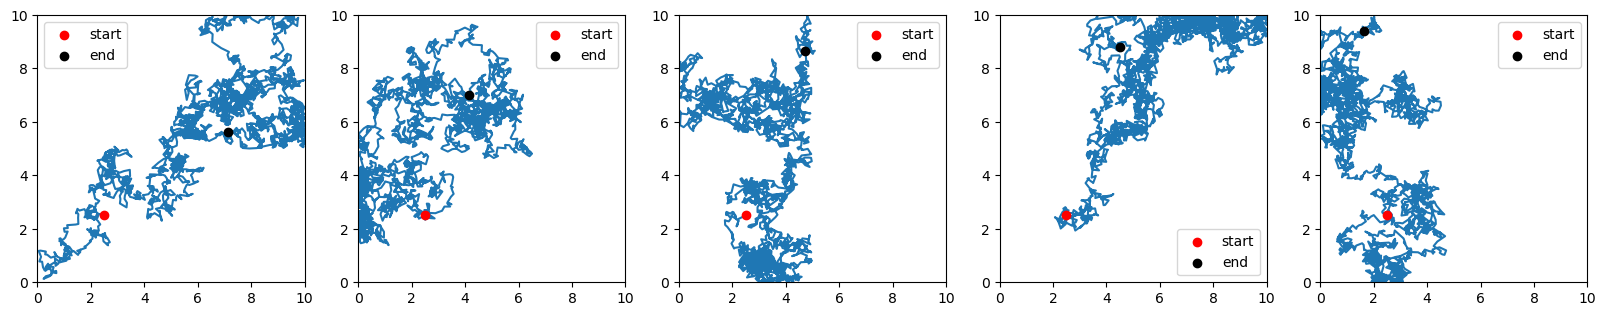

In [3]:
c = 1
fig = plt.figure(figsize=(20, 200))

for i in [1, 7, 13, 19, 25]:
    plt.subplot(1, 5, c)
    plt.plot(x[:, i], y[:, i], zorder=1)
    plt.scatter(x[0, i], y[0, i], c='r', label='start', zorder=2)
    plt.scatter(x[-1, i], y[-1, i], c='k', label='end', zorder=2)

    plt.xlim((0, L))
    plt.ylim((0, L))
    plt.legend()
    plt.gca().set_aspect('equal')

    c += 1

plt.show()

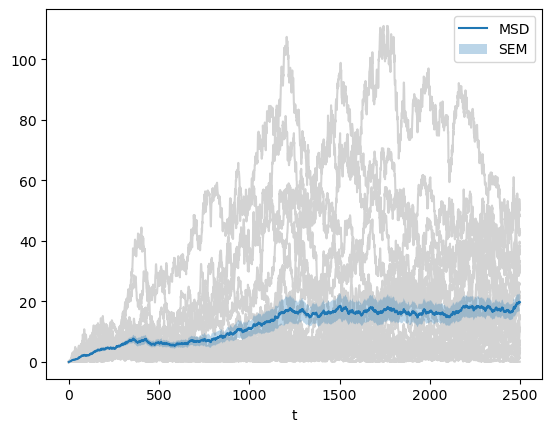

In [4]:
# 2) Calculating Mean Square Displacement

MSD = np.zeros_like(x[:, 0])
SEM = np.zeros_like(x[:, 0])

t = np.arange(0, Nt)

for j in range(N):
    r2_j = (x[:, j] - x[0, j])**2 + (y[:, j] - y[0, j])**2
    plt.plot(t, r2_j, color='#D3D3D3')

for i in range(Nt):
    r2 = (x[i, :] - x[0, :])**2 + (y[i, :] - y[0, :])**2
    MSD[i] = np.mean(r2)
    SEM[i] = np.std(r2)/np.sqrt(N)

plt.plot(t, MSD, label='MSD', zorder=3)
plt.fill_between(t, MSD - SEM, MSD + SEM, alpha=0.3, label='SEM', zorder=2)

plt.xlabel('t')
plt.legend()
plt.show()

In [5]:
# 3) Fitting the Anomalous Diffusion Exponent

def diffusionExponent(t):
    # Fit to MSD=c*t^alpha
    logt = np.log(t)
    logMSD = np.log(MSD[t])

    alpha, logc = np.polyfit(logt, logMSD, 1)

    return alpha, logc

Fitting to $\mathrm{MSD}(t)\approx ct^\alpha$

In [6]:
# 3.1 Short-time

t1 = np.arange(1, 20)
alpha1, logc1 = diffusionExponent(t1)
print(f"alpha = {alpha1}")
print(f"c = {np.exp(logc1)}")

alpha = 1.074440127654434
c = 0.024530158080238076


In [7]:
# 3.2 Intermediate-time

t2 = np.arange(20, 200)
alpha2, logc2 = diffusionExponent(t2)
print(f"alpha = {alpha2}")
print(f"c = {np.exp(logc2)}")

alpha = 0.9335231713029096
c = 0.031944530681459166


In [8]:
# 3.2 Long-time

t3 = np.arange(200, 2500)
alpha3, logc3 = diffusionExponent(t3)
print(f"alpha = {alpha3}")
print(f"c = {np.exp(logc3)}")

alpha = 0.6510918916919007
c = 0.12263675156274602


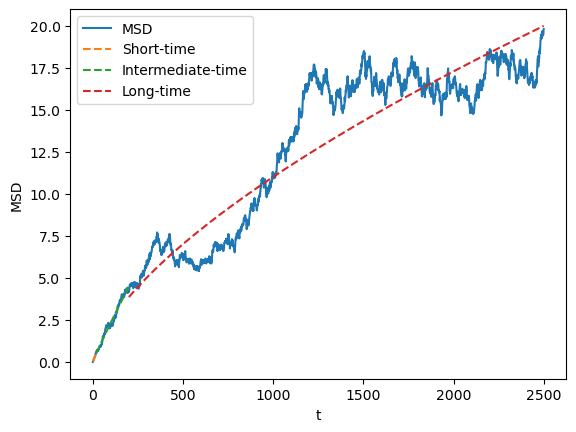

In [9]:
plt.plot(t, MSD, label='MSD')
plt.plot(t1, np.exp(logc1)*t1**alpha1, '--', label='Short-time')
plt.plot(t2, np.exp(logc2)*t2**alpha2, '--', label='Intermediate-time')
plt.plot(t3, np.exp(logc3)*t3**alpha3, '--', label='Long-time')

plt.xlabel('t')
plt.ylabel('MSD')
plt.legend()
plt.show()

In the short-time regime, the particles have not yet reached the compartment walls. Therefore, their motion is free Brownian diffusion with $\mathrm{MSD}(t)\approx 4Dt=2\sigma^2t$. The fitted diffusion exponent is $\alpha\approx 1.074$, which is consistent with normal diffusion $\alpha=1$. The fitted prefactor $c = 0.0245$ is slightly smaller than the theoretical value $2\sigma^2=0.0288$, which is expected because $\alpha$ and $c$ are correlated in the fit: the slightly large $\alpha$ is compensated by a smaller $c$.

In the intermediate-time regime, the fitted exponent is $\alpha\approx 0.934$, slightly smaller than $1$. This indicates the onset of subdiffusion. The time for a particle to diffuse over the half-width of compartment $(=2.5)$ is about $2.5^2/(2\sigma^2)=2.5^2/0.0288\approx 217$ steps. Therefore, a growing fraction of particles reaches to the vicinity of compartment wall in the end of this regime and blocked by the barrier in the buffer zone, which slows the growth of the MSD.

In the long-time regime, the fitted exponent is $\alpha\approx 0.651$, which is indicating strong subdiffusion. 